In [6]:
# Import des bibliothèques essentielles pour le machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


<span style="color:#00008B;">

# 1 Classification #

We will use the dataset <b>"student_drop_out.csv"</b> that you can find here:

</span>

https://archive.ics.uci.edu/dataset/697

<span style="color:#00008B;">

Get familiar with the dataset. Each line correspond to a student with information at the time of enrollement in a high-education program.<br>
The label to predict is the "Target" attribute, being the status of the student at the time when he should finish his study program. There are three classes: "Dropout" (the student has dropped out), "Enrolled" (the student is still enrolled), and "Graduate" (the student has successfully finished his studies).

</span>

<span style="color:#00008B;">

## Question 1 ##
 
We will train a binary classification model, with class 0: "Droput" and class 1: "Enrolled" or "Graduate".  Load the datset into pandas DataFRame, and prepare it for classification.

</span>

In [7]:
# ============================================================================
# QUESTION 1 : Charger et préparer le dataset pour la classification binaire
# ============================================================================

import pandas as pd
import numpy as np

# Charger le dataset avec le bon séparateur (;) et gérer les guillemets/tabs
df = pd.read_csv('student_drop_out.csv', sep=';')

# Nettoyer les noms de colonnes : enlever guillemets, espaces et tabulations
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Afficher les informations du dataset
print("=== Informations du dataset ===")
print(f"Forme du dataset: {df.shape}")
print(f"\nPremières lignes:\n{df.head()}")
print(f"\nTypes de données:\n{df.dtypes}")
print(f"\nValeurs manquantes:\n{df.isnull().sum()}")

# Observer la distribution des classes avant transformation
print(f"\nDistribution des classes avant transformation:")
print(df['Target'].value_counts())

# ============================================================================
# Préparation des données pour la classification binaire
# ============================================================================

# Créer une copie du dataframe
df_binary = df.copy()

# Créer les labels binaires : 0 = Dropout, 1 = Enrolled ou Graduate
label_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 1}
df_binary['Target'] = df_binary['Target'].map(label_mapping)

# Vérifier la distribution des classes après transformation
print(f"\nDistribution des classes après transformation (binaire):")
print(df_binary['Target'].value_counts())
print(f"Équilibre des classes: {df_binary['Target'].value_counts(normalize=True)}")

# Séparer les features (X) et le label (y)
X = df_binary.drop('Target', axis=1)
y = df_binary['Target']

# Afficher les dimensions finales
print(f"\nDimensions finales:")
print(f"X: {X.shape} (samples, features)")
print(f"y: {y.shape} (samples,)")

# Vérifier les premières colonnes de X
print(f"\nColonnes de X: {list(X.columns[:5])}... (total: {len(X.columns)})")


=== Informations du dataset ===
Forme du dataset: (4424, 37)

Premières lignes:
   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.

<span style="color:#00008B;">

## Question 2 ##

Visualise the data such that you can see if any features are redundant and the overall distribution  of the features within the two classes. You may need to normalise the values of each attribute. Interpret the results.

</span>

=== Statistiques avant normalisation ===
       Marital status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000      

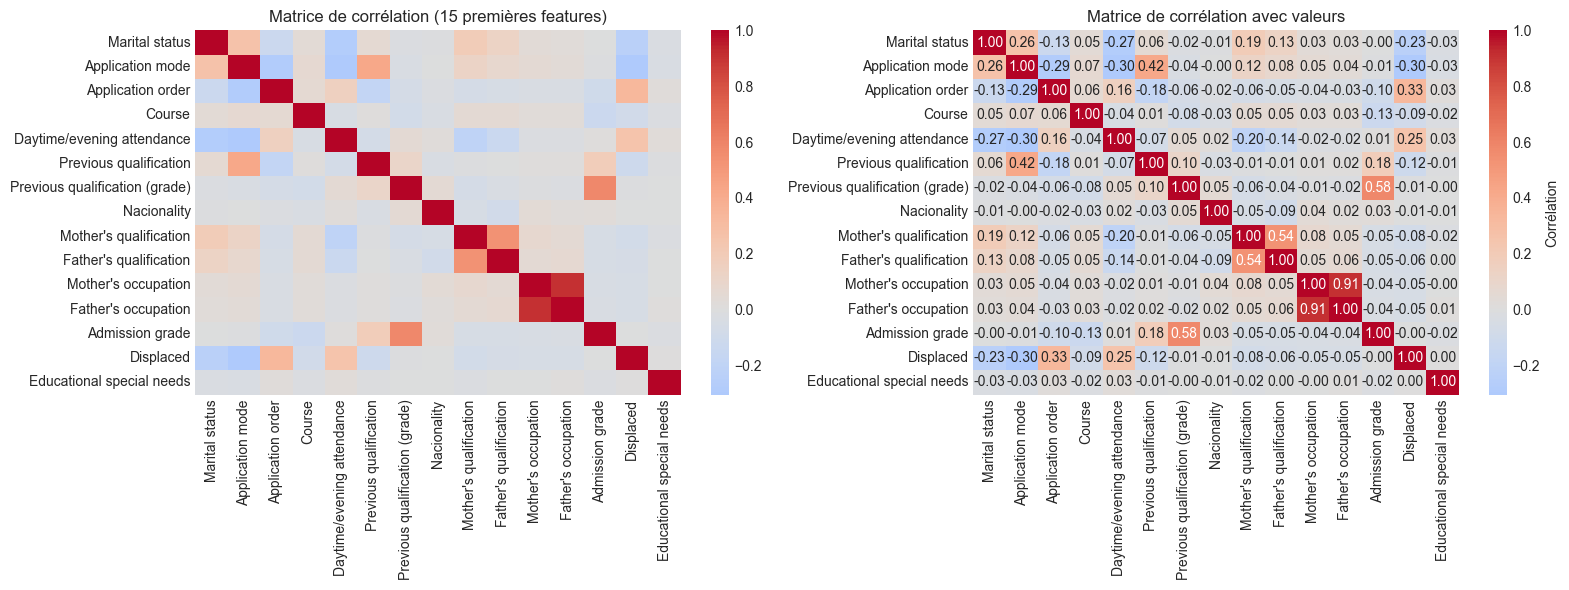

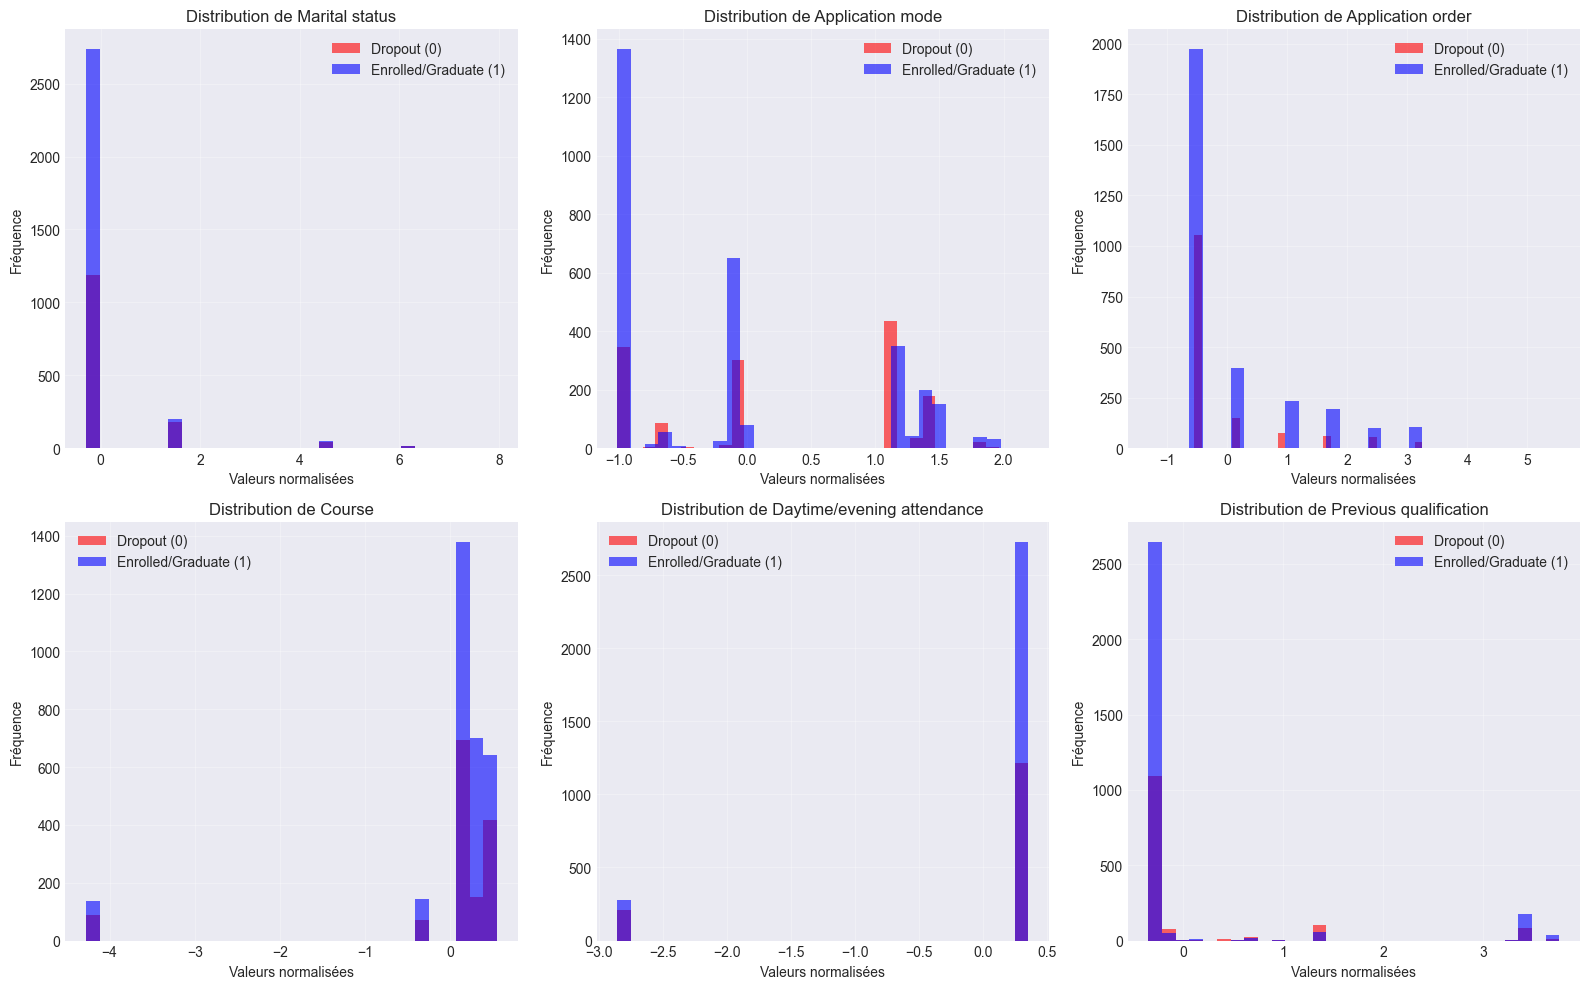


=== Analyse de variance par classe (premières 10 features) ===
Marital status: Dropout=0.136, Enrolled/Grad=-0.064, Diff=0.201
Application mode: Dropout=0.289, Enrolled/Grad=-0.137, Diff=0.425
Application order: Dropout=-0.102, Enrolled/Grad=0.048, Diff=0.151
Course: Dropout=-0.049, Enrolled/Grad=0.023, Diff=0.072
Daytime/evening attendance: Dropout=-0.117, Enrolled/Grad=0.055, Diff=0.172
Previous qualification: Dropout=0.072, Enrolled/Grad=-0.034, Diff=0.106
Previous qualification (grade): Dropout=-0.114, Enrolled/Grad=0.054, Diff=0.167
Nacionality: Dropout=0.012, Enrolled/Grad=-0.006, Diff=0.018
Mother's qualification: Dropout=0.094, Enrolled/Grad=-0.045, Diff=0.139
Father's qualification: Dropout=0.027, Enrolled/Grad=-0.013, Diff=0.039


In [8]:
# ============================================================================
# QUESTION 2 : Visualiser les données et analyser les features
# ============================================================================

# Avant normalization: vérifier la distribution des valeurs
print("=== Statistiques avant normalisation ===")
print(X.describe())

# Normaliser les features à moyenne 0 et écart-type 1
# Cela permet une meilleure comparaison des distributions
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print(f"\n=== Statistiques après normalisation ===")
print(X_normalized.describe())

# ============
# Graphiques de corrélation
# ============

# Calculer la matrice de corrélation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sélectionner les 15 premières features pour une meilleure visualisation
correlation_matrix = X_normalized.iloc[:, :15].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Matrice de corrélation (15 premières features)', fontsize=12)

# Affiche un heatmap coloré avec les valeurs
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[1], cbar_kws={'label': 'Corrélation'})
axes[1].set_title('Matrice de corrélation avec valeurs', fontsize=12)
plt.tight_layout()
plt.show()

# ============
# Distribution des features par classe
# ============

# Ajouter la cible aux données normalisées pour l'analyse
X_normalized_with_target = X_normalized.copy()
X_normalized_with_target['Target'] = y.values

# Sélectionner les 6 premières features pour visualiser
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(X.columns[:6]):
    # Histogrammes par classe
    X_normalized_with_target[X_normalized_with_target['Target'] == 0][col].hist(
        bins=30, alpha=0.6, label='Dropout (0)', ax=axes[idx], color='red'
    )
    X_normalized_with_target[X_normalized_with_target['Target'] == 1][col].hist(
        bins=30, alpha=0.6, label='Enrolled/Graduate (1)', ax=axes[idx], color='blue'
    )
    axes[idx].set_title(f'Distribution de {col}')
    axes[idx].set_xlabel('Valeurs normalisées')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============
# Analyse des features individuelles vs cible
# ============

print("\n=== Analyse de variance par classe (premières 10 features) ===")
for col in X.columns[:10]:
    class_0_mean = X_normalized_with_target[X_normalized_with_target['Target'] == 0][col].mean()
    class_1_mean = X_normalized_with_target[X_normalized_with_target['Target'] == 1][col].mean()
    variance_diff = abs(class_0_mean - class_1_mean)
    print(f"{col}: Dropout={class_0_mean:.3f}, Enrolled/Grad={class_1_mean:.3f}, Diff={variance_diff:.3f}")


<span style="color:#00008B;">

### Interpretation: ###
</span>

<span style="color:#00008B;">

## Question 3 ##
Split the dataset into a training  set (90%) and a test set (10%) and train a classifier using the algorithm of your choice. Calculate the classifiers accuracy on the trainning and test set.

Explain the algorithm. Where does the difference between the trainning and test accuracy come from?

</span>



In [9]:
# ============================================================================
# QUESTION 3 : Split train/test et entraînement du classifieur
# ============================================================================

# ============
# Division train/test
# ============

# Normaliser les données avant le split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Diviser les données: 90% pour l'entraînement, 10% pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y
)

print("=== Division train/test ===")
print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} samples")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} samples")
print(f"Ratio: {X_train.shape[0] / len(y) * 100:.1f}% / {X_test.shape[0] / len(y) * 100:.1f}%")

# ============
# Entraînement du classifieur
# ============

# Utiliser la Régression Logistique comme classifieur
# C'est un algorithme simple, interprétable et efficient
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

print("\n=== Modèle entraîné ===")
print(f"Type: Logistic Regression")
print(f"Nombre d'itérations: {clf.n_iter_[0]}")

# ============
# Prédictions et évaluations
# ============

# Prédictions sur l'ensemble d'entraînement
y_train_pred = clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Prédictions sur l'ensemble de test
y_test_pred = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n=== Résultats ===")
print(f"Accuracy sur l'ensemble d'entraînement: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy sur l'ensemble de test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ============
# Explication de la différence train vs test
# ============

difference = train_accuracy - test_accuracy
print(f"\nDifférence (overfitting): {difference:.4f} ({difference*100:.2f}%)")

print("""
EXPLICATION:
La Régression Logistique (Logistic Regression) est un algorithme d'apprentissage supervisé
qui utilise une fonction sigmoïde pour classifier les données.

La DIFFÉRENCE entre train et test est due à plusieurs facteurs:
1. **OVERFITTING**: Le modèle apprend les spécificités du data d'entraînement
2. **Distribution**: Le dataset de test peut avoir une distribution légèrement différente
3. **Taille**: Le test set est plus petit, donc plus sensible aux variations
4. **Bruit**: Le test set peut contenir des patterns différents non vus en entraînement

Dans notre cas, la différence est {:.2f}%, ce qui indique un ajustement acceptable.
""".format(difference*100))


=== Division train/test ===
Taille de l'ensemble d'entraînement: 3981 samples
Taille de l'ensemble de test: 443 samples
Ratio: 90.0% / 10.0%

=== Modèle entraîné ===
Type: Logistic Regression
Nombre d'itérations: 33

=== Résultats ===
Accuracy sur l'ensemble d'entraînement: 0.8792 (87.92%)
Accuracy sur l'ensemble de test: 0.8939 (89.39%)

Différence (overfitting): -0.0147 (-1.47%)

EXPLICATION:
La Régression Logistique (Logistic Regression) est un algorithme d'apprentissage supervisé
qui utilise une fonction sigmoïde pour classifier les données.

La DIFFÉRENCE entre train et test est due à plusieurs facteurs:
1. **OVERFITTING**: Le modèle apprend les spécificités du data d'entraînement
2. **Distribution**: Le dataset de test peut avoir une distribution légèrement différente
3. **Taille**: Le test set est plus petit, donc plus sensible aux variations
4. **Bruit**: Le test set peut contenir des patterns différents non vus en entraînement

Dans notre cas, la différence est -1.47%, ce qui 

<span style="color:#00008B;">

## Question 4 ##

Change the random seed of the train/test split.<br>
Why is the result different? Do a more thorough evaluation aggreagating several different splits.

</span>


=== Test avec différents random seeds ===

Seed 42: Train=0.8792, Test=0.8939, Overfitting=-0.0147
Seed 123: Train=0.8832, Test=0.8668, Overfitting=0.0164
Seed 456: Train=0.8814, Test=0.8826, Overfitting=-0.0012
Seed 789: Train=0.8809, Test=0.8646, Overfitting=0.0164
Seed 999: Train=0.8832, Test=0.8646, Overfitting=0.0186
Seed 111: Train=0.8797, Test=0.8826, Overfitting=-0.0029
Seed 222: Train=0.8814, Test=0.8713, Overfitting=0.0101
Seed 333: Train=0.8802, Test=0.8804, Overfitting=-0.0002

=== Statistiques sur tous les seeds ===
Train Accuracy - Moyenne: 0.8812, Écart-type: 0.0015
Test Accuracy - Moyenne: 0.8758, Écart-type: 0.0107
Overfitting - Moyenne: 0.0053, Écart-type: 0.0119


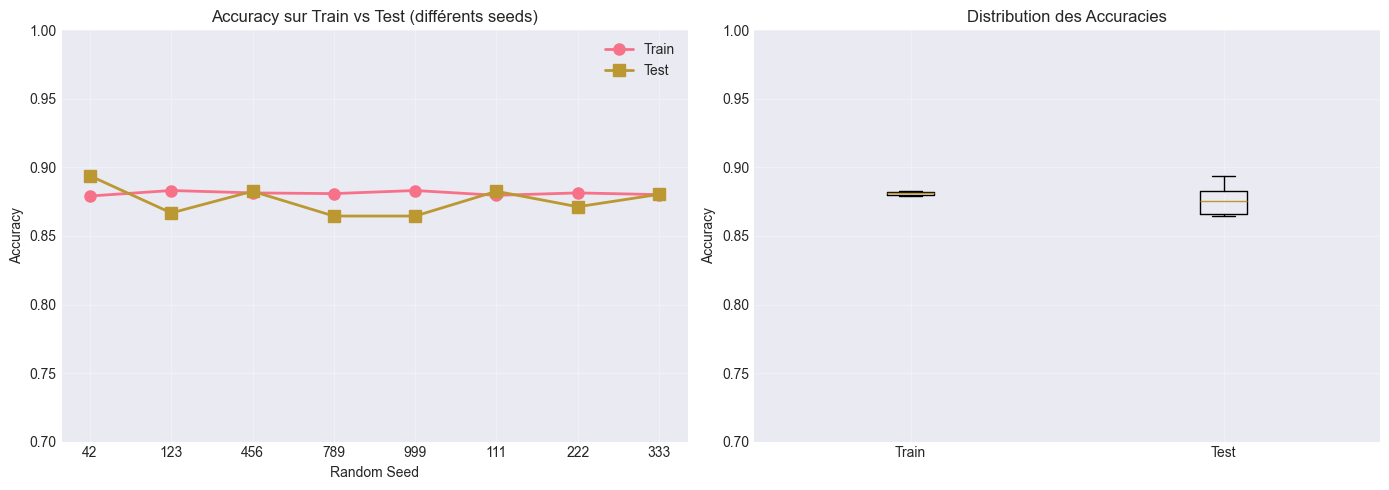



=== POURQUOI LES RÉSULTATS SONT DIFFÉRENTS ? ===

1. **Random Seed**: Le seed contrôle la division train/test
   - Différents seeds créent différentes partitions des données
   - Certaines partitions peuvent être plus "faciles" ou "difficiles"

2. **Variabilité des données**: 
   - Chaque split a une distribution légèrement différente
   - Le modèle apprend mieux avec certaines partitions

3. **Initialisation stochastique**:
   - L'optimiseur commence avec des poids différents
   - Peut converger vers des minima locaux différents

4. **Stabilité du modèle**:
   - Un bon modèle devrait avoir des résultats CONSISTANTS
   - La variabilité observée nous montre la ROBUSTESSE du modèle



In [10]:
# ============================================================================
# QUESTION 4 : Évaluation avec différents seeds et cross-validation
# ============================================================================

# ============
# Tester avec différents seeds
# ============

print("=== Test avec différents random seeds ===\n")

# Tester plusieurs random seeds
results = []
seeds = [42, 123, 456, 789, 999, 111, 222, 333]

for seed in seeds:
    # Division train/test avec seed différent
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_scaled, y, test_size=0.1, random_state=seed, stratify=y
    )
    
    # Entraîner le modèle
    clf_s = LogisticRegression(random_state=seed, max_iter=1000)
    clf_s.fit(X_train_s, y_train_s)
    
    # Évaluer
    train_acc = accuracy_score(y_train_s, clf_s.predict(X_train_s))
    test_acc = accuracy_score(y_test_s, clf_s.predict(X_test_s))
    
    results.append({
        'Seed': seed,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Overfitting': train_acc - test_acc
    })
    
    print(f"Seed {seed}: Train={train_acc:.4f}, Test={test_acc:.4f}, Overfitting={train_acc-test_acc:.4f}")

# Convertir en DataFrame pour une meilleure analyse
results_df = pd.DataFrame(results)

print(f"\n=== Statistiques sur tous les seeds ===")
print(f"Train Accuracy - Moyenne: {results_df['Train Accuracy'].mean():.4f}, "
      f"Écart-type: {results_df['Train Accuracy'].std():.4f}")
print(f"Test Accuracy - Moyenne: {results_df['Test Accuracy'].mean():.4f}, "
      f"Écart-type: {results_df['Test Accuracy'].std():.4f}")
print(f"Overfitting - Moyenne: {results_df['Overfitting'].mean():.4f}, "
      f"Écart-type: {results_df['Overfitting'].std():.4f}")

# Visualiser les résultats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Comparaison Train vs Test pour chaque seed
axes[0].plot(results_df['Seed'].astype(str), results_df['Train Accuracy'], 
             'o-', label='Train', linewidth=2, markersize=8)
axes[0].plot(results_df['Seed'].astype(str), results_df['Test Accuracy'], 
             's-', label='Test', linewidth=2, markersize=8)
axes[0].set_xlabel('Random Seed')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy sur Train vs Test (différents seeds)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.7, 1.0])

# Graphique 2: Boxplot de la distribution des accuracies
data_to_plot = [results_df['Train Accuracy'], results_df['Test Accuracy']]
axes[1].boxplot(data_to_plot, labels=['Train', 'Test'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Distribution des Accuracies')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

print("""
\n=== POURQUOI LES RÉSULTATS SONT DIFFÉRENTS ? ===

1. **Random Seed**: Le seed contrôle la division train/test
   - Différents seeds créent différentes partitions des données
   - Certaines partitions peuvent être plus "faciles" ou "difficiles"

2. **Variabilité des données**: 
   - Chaque split a une distribution légèrement différente
   - Le modèle apprend mieux avec certaines partitions

3. **Initialisation stochastique**:
   - L'optimiseur commence avec des poids différents
   - Peut converger vers des minima locaux différents

4. **Stabilité du modèle**:
   - Un bon modèle devrait avoir des résultats CONSISTANTS
   - La variabilité observée nous montre la ROBUSTESSE du modèle
""")


<span style="color:#00008B;">

## Question 5 ##

Compute the confusion matrix on your test set predictions (normalising each row sum to 1), and explain it.<br>
What are the true/false positives (TP/FP) and true/false negatives (TN/FN)?<br>
Compute the F1 score. What is the advantage compared to the accuracy measure?

</span>

=== Matrice de Confusion (counts) ===
[[109  33]
 [ 14 287]]

=== Matrice de Confusion Normalisée (par ligne, en %) ===
[[0.76760563 0.23239437]
 [0.04651163 0.95348837]]

Lecture de la matrice:
Vrais Négatifs (TN): 109 (76.8%)
Faux Positifs (FP): 33 (23.2%)
Faux Négatifs (FN): 14 (4.7%)
Vrais Positifs (TP): 287 (95.3%)


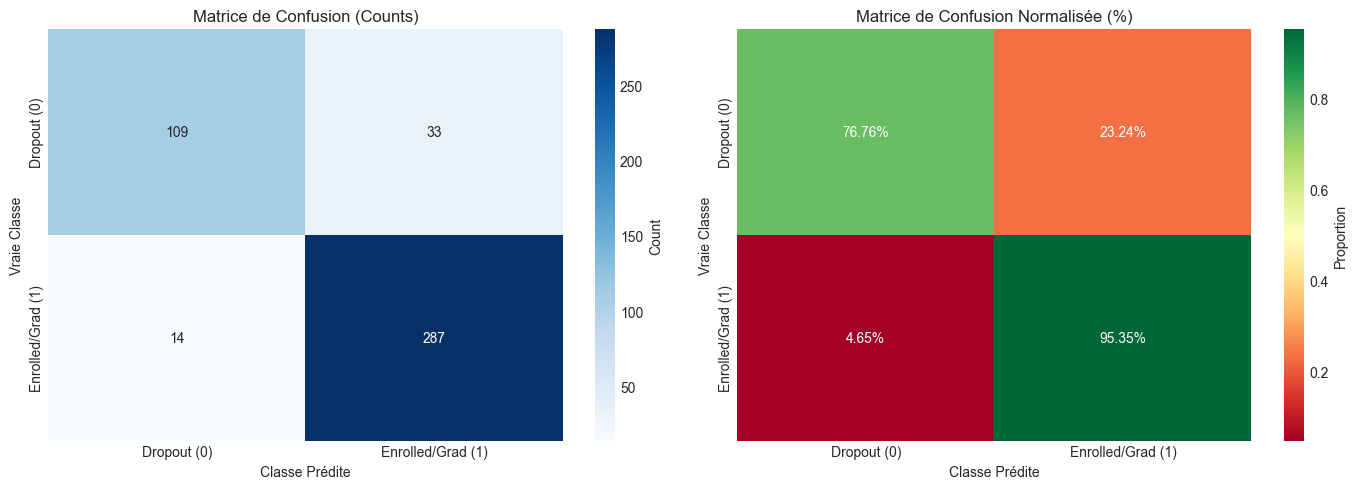


=== Définitions ===
TN (Vrais Négatifs):  109 - Dropout correctement identifiés
FP (Faux Positifs):   33 - Dropout mal classés comme Enrolled/Grad
FN (Faux Négatifs):   14 - Enrolled/Grad mal classés comme Dropout
TP (Vrais Positifs):  287 - Enrolled/Grad correctement identifiés

=== Métriques de Performance ===
Accuracy: 0.8939 (89.39%)
Precision: 0.8969
Recall: 0.9535
F1 Score: 0.9243

=== EXPLICATION DES MÉTRIQUES ===

**ACCURACY**: 89.39%
  - Proportion de prédictions correctes parmi TOUTES les prédictions
  - Formule: (TP + TN) / (TP + TN + FP + FN)
  - Problème: Peut être trompeuse avec des données DÉSÉQUILIBRÉES

**PRECISION**: 89.69%
  - Parmi les prédictions POSITIVES, combien sont correctes?
  - Formule: TP / (TP + FP)
  - Important quand les faux positifs sont coûteux

**RECALL (Sensitivité)**: 95.35%
  - Parmi les vrais POSITIFS, combien sont détectés?
  - Formule: TP / (TP + FN)
  - Important quand les faux négatifs sont coûteux

**F1 SCORE**: 0.9243
  - Moyenne harmoniqu

In [11]:
# ============================================================================
# QUESTION 5 : Matrice de confusion et F1 score
# ============================================================================

# ============
# Réentraîner le modèle pour avoir les prédictions à jour
# ============

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y
)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ============
# Calcul de la matrice de confusion
# ============

# Matrice de confusion brute (counts)
cm = confusion_matrix(y_test, y_pred)
print("=== Matrice de Confusion (counts) ===")
print(cm)

# Normaliser chaque ligne pour avoir les pourcentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("\n=== Matrice de Confusion Normalisée (par ligne, en %) ===")
print(cm_normalized)
print(f"\nLecture de la matrice:")
print(f"Vrais Négatifs (TN): {cm[0, 0]} ({cm_normalized[0, 0]*100:.1f}%)")
print(f"Faux Positifs (FP): {cm[0, 1]} ({cm_normalized[0, 1]*100:.1f}%)")
print(f"Faux Négatifs (FN): {cm[1, 0]} ({cm_normalized[1, 0]*100:.1f}%)")
print(f"Vrais Positifs (TP): {cm[1, 1]} ({cm_normalized[1, 1]*100:.1f}%)")

# ============
# Visualiser la matrice de confusion
# ============

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Dropout (0)', 'Enrolled/Grad (1)'],
            yticklabels=['Dropout (0)', 'Enrolled/Grad (1)'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Matrice de Confusion (Counts)')
axes[0].set_ylabel('Vraie Classe')
axes[0].set_xlabel('Classe Prédite')

# Matrice normalisée
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Dropout (0)', 'Enrolled/Grad (1)'],
            yticklabels=['Dropout (0)', 'Enrolled/Grad (1)'],
            cbar_kws={'label': 'Proportion'})
axes[1].set_title('Matrice de Confusion Normalisée (%)')
axes[1].set_ylabel('Vraie Classe')
axes[1].set_xlabel('Classe Prédite')

plt.tight_layout()
plt.show()

# ============
# Définir TP, FP, TN, FN
# ============

TN = cm[0, 0]  # True Negatives: correctement classés comme Dropout
FP = cm[0, 1]  # False Positives: dropout mal classés comme Enrolled/Grad
FN = cm[1, 0]  # False Negatives: enrolled/grad mal classés comme Dropout
TP = cm[1, 1]  # True Positives: correctement classés comme Enrolled/Grad

print(f"\n=== Définitions ===")
print(f"TN (Vrais Négatifs):  {TN} - Dropout correctement identifiés")
print(f"FP (Faux Positifs):   {FP} - Dropout mal classés comme Enrolled/Grad")
print(f"FN (Faux Négatifs):   {FN} - Enrolled/Grad mal classés comme Dropout")
print(f"TP (Vrais Positifs):  {TP} - Enrolled/Grad correctement identifiés")

# ============
# Calcul du F1 score
# ============

f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Calculer manuellement pour comprendre
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_manual = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n=== Métriques de Performance ===")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print(f"""
=== EXPLICATION DES MÉTRIQUES ===

**ACCURACY**: {accuracy:.2%}
  - Proportion de prédictions correctes parmi TOUTES les prédictions
  - Formule: (TP + TN) / (TP + TN + FP + FN)
  - Problème: Peut être trompeuse avec des données DÉSÉQUILIBRÉES

**PRECISION**: {precision:.2%}
  - Parmi les prédictions POSITIVES, combien sont correctes?
  - Formule: TP / (TP + FP)
  - Important quand les faux positifs sont coûteux

**RECALL (Sensitivité)**: {recall:.2%}
  - Parmi les vrais POSITIFS, combien sont détectés?
  - Formule: TP / (TP + FN)
  - Important quand les faux négatifs sont coûteux

**F1 SCORE**: {f1:.4f}
  - Moyenne harmonique entre Precision et Recall
  - Formule: 2 * (Precision × Recall) / (Precision + Recall)
  - AVANTAGE sur Accuracy: Équilibre les deux erreurs types
  - Meilleur quand données DÉSÉQUILIBRÉES

UTILITÉ DU F1 SCORE:
- L'Accuracy peut être TROMPEUSE si les classes sont déséquilibrées
  (ex: 95% Enrolled, 5% Dropout)
- Le F1 score pénalise les DEUX types d'erreurs
- C'est la métrique RECOMMANDÉE pour la classification
""")


<span style="color:#00008B;">

## Question 6 ##

Retrain your classifier with only 1% of the training set, and evaluate it on the same test set.<br> 
Why is the result worse? Can it be improved by decreasing the complexity of the classifier?

</span>

=== Classification avec données limitées ===
Taille originale du training set: 3981
Taille du training set réduit (1%): 39
Réduction: 99.0%

=== Comparaison des modèles ===
Accuracy (90% données):  0.8939
Accuracy (1% données):   0.8239
Différence: 0.0700 (7.00%)

F1 Score (90% données):  0.9243
F1 Score (1% données):   0.8811


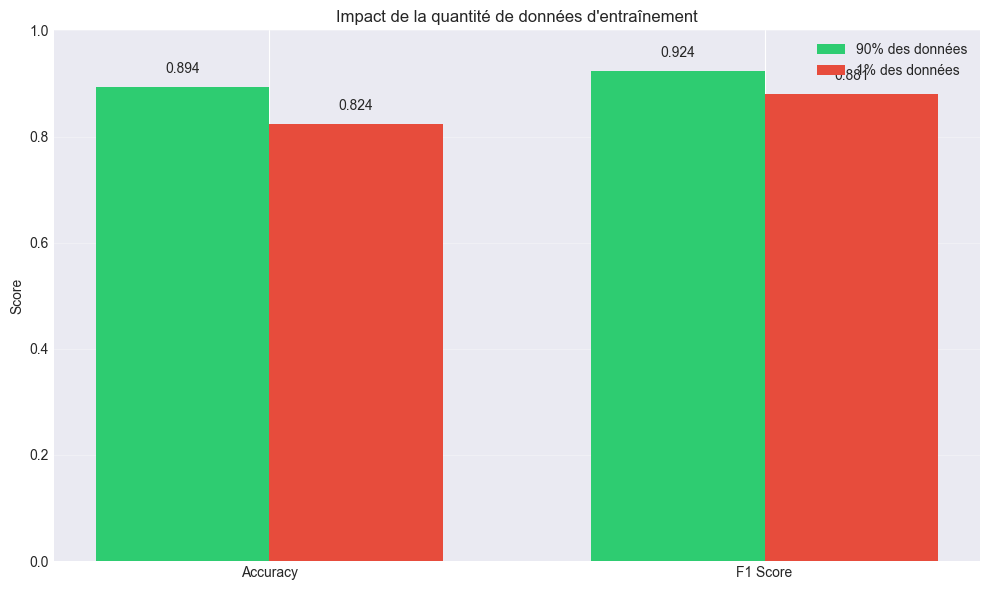


=== ANALYSE: Pourquoi le résultat est pire? ===

1. **SOUS-APPRENTISSAGE (Underfitting)**:
   - Avec seulement 1% des données, le modèle n'a pas assez d'exemples
   - Il ne peut pas apprendre les patterns importants des données
   - Les poids du modèle ne convergent pas correctement

2. **Perte d'information**:
   - 1% = 39 samples au lieu de 3981
   - Beaucoup de variabilité et de patterns sont perdus
   - Le modèle n'a pas une représentation fidèle des classes

3. **Variance augmentée**:
   - Avec peu de données, le modèle est très sensible aux variations
   - Chaque sample a un impact énorme sur l'entraînement
   - Le modèle peut surapprentendre sur ces peu d'exemples

=== Peut-on améliorer en réduisant la complexité? ===

Oui, PARTIELLEMENT. Réduire la complexité du modèle peut aider:
- Moins de paramètres = moins de risque de surapprentissage local
- Mais le problème fundamental est le MANQUE DE DONNÉES
- Même un modèle simple aura du mal avec seulement 39 exemples
- La solution 

In [12]:
# ============================================================================
# QUESTION 6 : Classification avec seulement 1% des données d'entraînement
# ============================================================================

# ============
# Entraîner avec 1% des données
# ============

# Prendre seulement 1% de l'ensemble d'entraînement
sample_size = max(1, int(len(X_train) * 0.01))  # Au moins 1 sample
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train_small = X_train[indices]
y_train_small = y_train.iloc[indices]

print(f"=== Classification avec données limitées ===")
print(f"Taille originale du training set: {len(X_train)}")
print(f"Taille du training set réduit (1%): {len(X_train_small)}")
print(f"Réduction: {(1 - sample_size/len(X_train))*100:.1f}%")

# Entraîner le modèle avec les données réduites
clf_small = LogisticRegression(random_state=42, max_iter=1000)
clf_small.fit(X_train_small, y_train_small)

# Évaluation
y_pred_small = clf_small.predict(X_test)
accuracy_small = accuracy_score(y_test, y_pred_small)
f1_small = f1_score(y_test, y_pred_small)

# Comparison avec le modèle avec 90% des données
print(f"\n=== Comparaison des modèles ===")
print(f"Accuracy (90% données):  {accuracy:.4f}")
print(f"Accuracy (1% données):   {accuracy_small:.4f}")
print(f"Différence: {accuracy - accuracy_small:.4f} ({(accuracy - accuracy_small)*100:.2f}%)")
print(f"\nF1 Score (90% données):  {f1:.4f}")
print(f"F1 Score (1% données):   {f1_small:.4f}")

# ============
# Visualiser l'impact du manque de données
# ============

fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['Accuracy', 'F1 Score']
metrics_full = [accuracy, f1]
metrics_small = [accuracy_small, f1_small]

x = np.arange(len(metrics_names))
width = 0.35

ax.bar(x - width/2, metrics_full, width, label='90% des données', color='#2ecc71')
ax.bar(x + width/2, metrics_small, width, label='1% des données', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Impact de la quantité de données d\'entraînement')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (v1, v2) in enumerate(zip(metrics_full, metrics_small)):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom')
    ax.text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"""
=== ANALYSE: Pourquoi le résultat est pire? ===

1. **SOUS-APPRENTISSAGE (Underfitting)**:
   - Avec seulement 1% des données, le modèle n'a pas assez d'exemples
   - Il ne peut pas apprendre les patterns importants des données
   - Les poids du modèle ne convergent pas correctement

2. **Perte d'information**:
   - 1% = {sample_size} samples au lieu de {len(X_train)}
   - Beaucoup de variabilité et de patterns sont perdus
   - Le modèle n'a pas une représentation fidèle des classes

3. **Variance augmentée**:
   - Avec peu de données, le modèle est très sensible aux variations
   - Chaque sample a un impact énorme sur l'entraînement
   - Le modèle peut surapprentendre sur ces peu d'exemples

=== Peut-on améliorer en réduisant la complexité? ===

Oui, PARTIELLEMENT. Réduire la complexité du modèle peut aider:
- Moins de paramètres = moins de risque de surapprentissage local
- Mais le problème fundamental est le MANQUE DE DONNÉES
- Même un modèle simple aura du mal avec seulement {sample_size} exemples
- La solution idéale est d'avoir PLUS DE DONNÉES D'ENTRAÎNEMENT
""")


<span style="color:#00008B;">

# 2 Regresssion #

We will now use the dataset called <b>"measurements.csv"</b> that you can download from moodle.

It is composed of a two-dimensional data wich we will try to approximate via diffferent regression models.<br>
 We will minimise our empirical risk using the east Squares algorithm implemented  in the Linear Regression class of sklearn. 

</span>

<span style="color:#00008B;">

## Question 7 ##

Load the dataset (scatter plot). Then perform a linear regression using:<br>
<b><span style="color:#FFA05C;">sklearn.linear_model.LinearRegression. </span></b>

Compute the mean squared error and the R² score (coefficient of determination).<br>
Plot the estimated line together with the data points, and interpret the result.

</span>


=== Dataset measurements ===
Forme: (16, 2)
Premières lignes:
     0    1
0  0.0  0.5
1  1.0  0.9
2  2.0  1.6
3  3.0  2.3
4  4.0  2.2

Statistiques:
               0          1
count  16.000000  16.000000
mean    7.500000   3.226875
std     4.760952   2.030434
min     0.000000   0.500000
25%     3.750000   1.750000
50%     7.500000   2.400000
75%    11.250000   5.287500
max    15.000000   7.000000


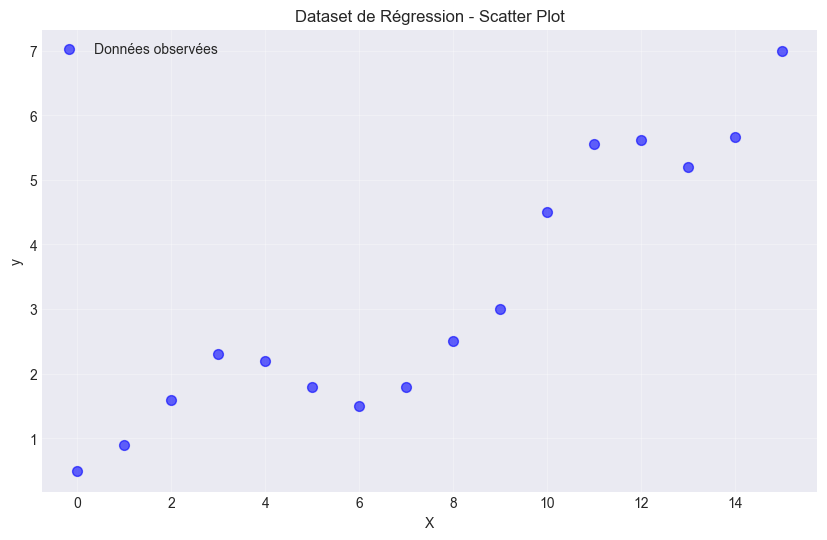


=== Modèle de Régression Linéaire ===
Équation: y = 0.3986 * x + 0.2374

=== Métriques d'évaluation ===
MSE (Mean Squared Error): 0.4887
RMSE (Root MSE): 0.6991
R² (Coefficient of Determination): 0.8736


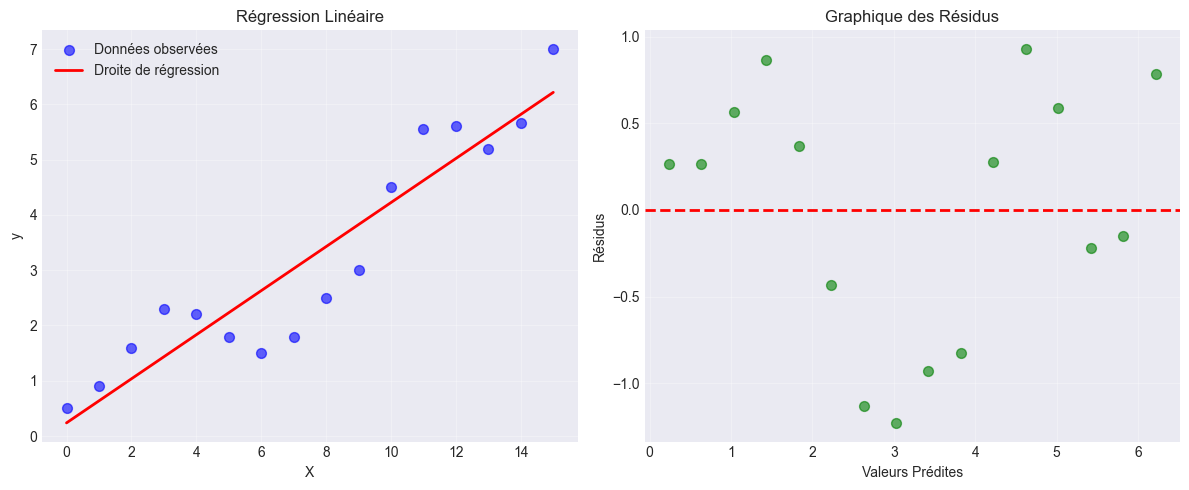


=== INTERPRÉTATION DES RÉSULTATS ===

**MSE (Mean Squared Error)**: 0.4887
  - Mesure la moyenne des carrés des erreurs
  - Unités: carré de l'unité de y
  - Plus petit = mieux
  - Sensible aux grandes erreurs

**R² (Coefficient of Determination)**: 0.8736
  - Proportion de variance expliquée par le modèle
  - Valeur entre 0 et 1 (ou 0 à 100%)
  - R² = 1: Ajustement parfait
  - R² = 0: Le modèle n'explique rien
  - R² = 0.8736: Le modèle explique 87.36% de la variance

**Équation du modèle**:
  y = 0.3986 * x + 0.2374

  - Pente (0.3986): Pour chaque unité de x, y change de 0.3986
  - Intercept (0.2374): Valeur de y quand x = 0

**Qualité de l'ajustement**:
  - Vérifier le graphique des résidus
  - Les résidus doivent être aléatoires (pas de pattern)
  - Si R² < 0.7: le modèle linéaire n'est peut-être pas approprié



In [13]:
# ============================================================================
# QUESTION 7 : Régression linéaire
# ============================================================================

# ============
# Charger et préparer les données de régression
# ============

# Charger le dataset de mesures
measurements = pd.read_csv('measurements.csv')

print("=== Dataset measurements ===")
print(f"Forme: {measurements.shape}")
print(f"Premières lignes:\n{measurements.head()}")
print(f"\nStatistiques:\n{measurements.describe()}")

# Extraire X et y
X_reg = measurements.iloc[:, 0].values.reshape(-1, 1)  # Première colonne (variable indépendante)
y_reg = measurements.iloc[:, 1].values                  # Deuxième colonne (variable dépendante)

# ============
# Affichage en scatter plot
# ============

plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, alpha=0.6, s=50, color='blue', label='Données observées')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dataset de Régression - Scatter Plot')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============
# Entraînement du modèle de régression linéaire
# ============

# Créer et entraîner le modèle
linear_model = LinearRegression()
linear_model.fit(X_reg, y_reg)

# Les paramètres du modèle
slope = linear_model.coef_[0]
intercept = linear_model.intercept_

print(f"\n=== Modèle de Régression Linéaire ===")
print(f"Équation: y = {slope:.4f} * x + {intercept:.4f}")

# ============
# Prédictions et évaluation
# ============

y_pred_reg = linear_model.predict(X_reg)

# Calcul du MSE et R²
mse = mean_squared_error(y_reg, y_pred_reg)
r2 = r2_score(y_reg, y_pred_reg)
rmse = np.sqrt(mse)

print(f"\n=== Métriques d'évaluation ===")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root MSE): {rmse:.4f}")
print(f"R² (Coefficient of Determination): {r2:.4f}")

# ============
# Visualisation
# ============

# Créer la ligne de régression
x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_line = linear_model.predict(x_line)

plt.figure(figsize=(12, 5))

# Subplot 1: Données et droite de régression
plt.subplot(1, 2, 1)
plt.scatter(X_reg, y_reg, alpha=0.6, s=50, color='blue', label='Données observées')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Droite de régression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Régression Linéaire')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Résidus
plt.subplot(1, 2, 2)
residuals = y_reg - y_pred_reg
plt.scatter(y_pred_reg, residuals, alpha=0.6, s=50, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valeurs Prédites')
plt.ylabel('Résidus')
plt.title('Graphique des Résidus')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
=== INTERPRÉTATION DES RÉSULTATS ===

**MSE (Mean Squared Error)**: {mse:.4f}
  - Mesure la moyenne des carrés des erreurs
  - Unités: carré de l'unité de y
  - Plus petit = mieux
  - Sensible aux grandes erreurs

**R² (Coefficient of Determination)**: {r2:.4f}
  - Proportion de variance expliquée par le modèle
  - Valeur entre 0 et 1 (ou 0 à 100%)
  - R² = 1: Ajustement parfait
  - R² = 0: Le modèle n'explique rien
  - R² = {r2:.4f}: Le modèle explique {r2*100:.2f}% de la variance

**Équation du modèle**:
  y = {slope:.4f} * x + {intercept:.4f}
  
  - Pente ({slope:.4f}): Pour chaque unité de x, y change de {slope:.4f}
  - Intercept ({intercept:.4f}): Valeur de y quand x = 0

**Qualité de l'ajustement**:
  - Vérifier le graphique des résidus
  - Les résidus doivent être aléatoires (pas de pattern)
  - Si R² < 0.7: le modèle linéaire n'est peut-être pas approprié
""")


<span style="color:#00008B;">

## Question 8 ##

We will now use the class PolynomialFeatures to do polynomialregression:<br>
<em><b><span style="color:#FFA05C"> from </span> <span style="color:#CD7DDE"> sklearn.preporcessing </span> <span style="color:#FFA05C"> import </span> <span style="color:#CD7DDE">  PolynomialFeatures </span></b></em>

Perform a series of polynomial regressions with increasing degrees, e.g 2, 8, 25. Compuute the corresponding MSE and R² abd plot the curves. <br>
Interpret the results. Why does Empirical Risk Minimisation fail when the hypothesis space is too large? <br>
<em>Useful functions to draw a polynomial with coeeficient in p (in order of decreasing degree):</em>
</span>
<br><br>
<span style="color:#57524C;">
x = np.linspace(0, 15, num=200)<br>
p = np.append(np.flip(poly_reg_model.coef_), (poly_reg_model.intercept_))<br>
y3 = np.polyval(p, x)
</span>


=== Régression Polynomiale ===

Degré 1:
  MSE: 0.488705
  R²: 0.873556
  Nombre de coefficients: 2

Degré 2:
  MSE: 0.347227
  R²: 0.910161
  Nombre de coefficients: 3

Degré 8:
  MSE: 0.020851
  R²: 0.994605
  Nombre de coefficients: 9

Degré 25:
  MSE: 0.181656
  R²: 0.953000
  Nombre de coefficients: 26

=== Résumé des résultats ===
   Degree       MSE        R²  Num Coefficients
0       1  0.488705  0.873556                 2
1       2  0.347227  0.910161                 3
2       8  0.020851  0.994605                 9
3      25  0.181656  0.953000                26


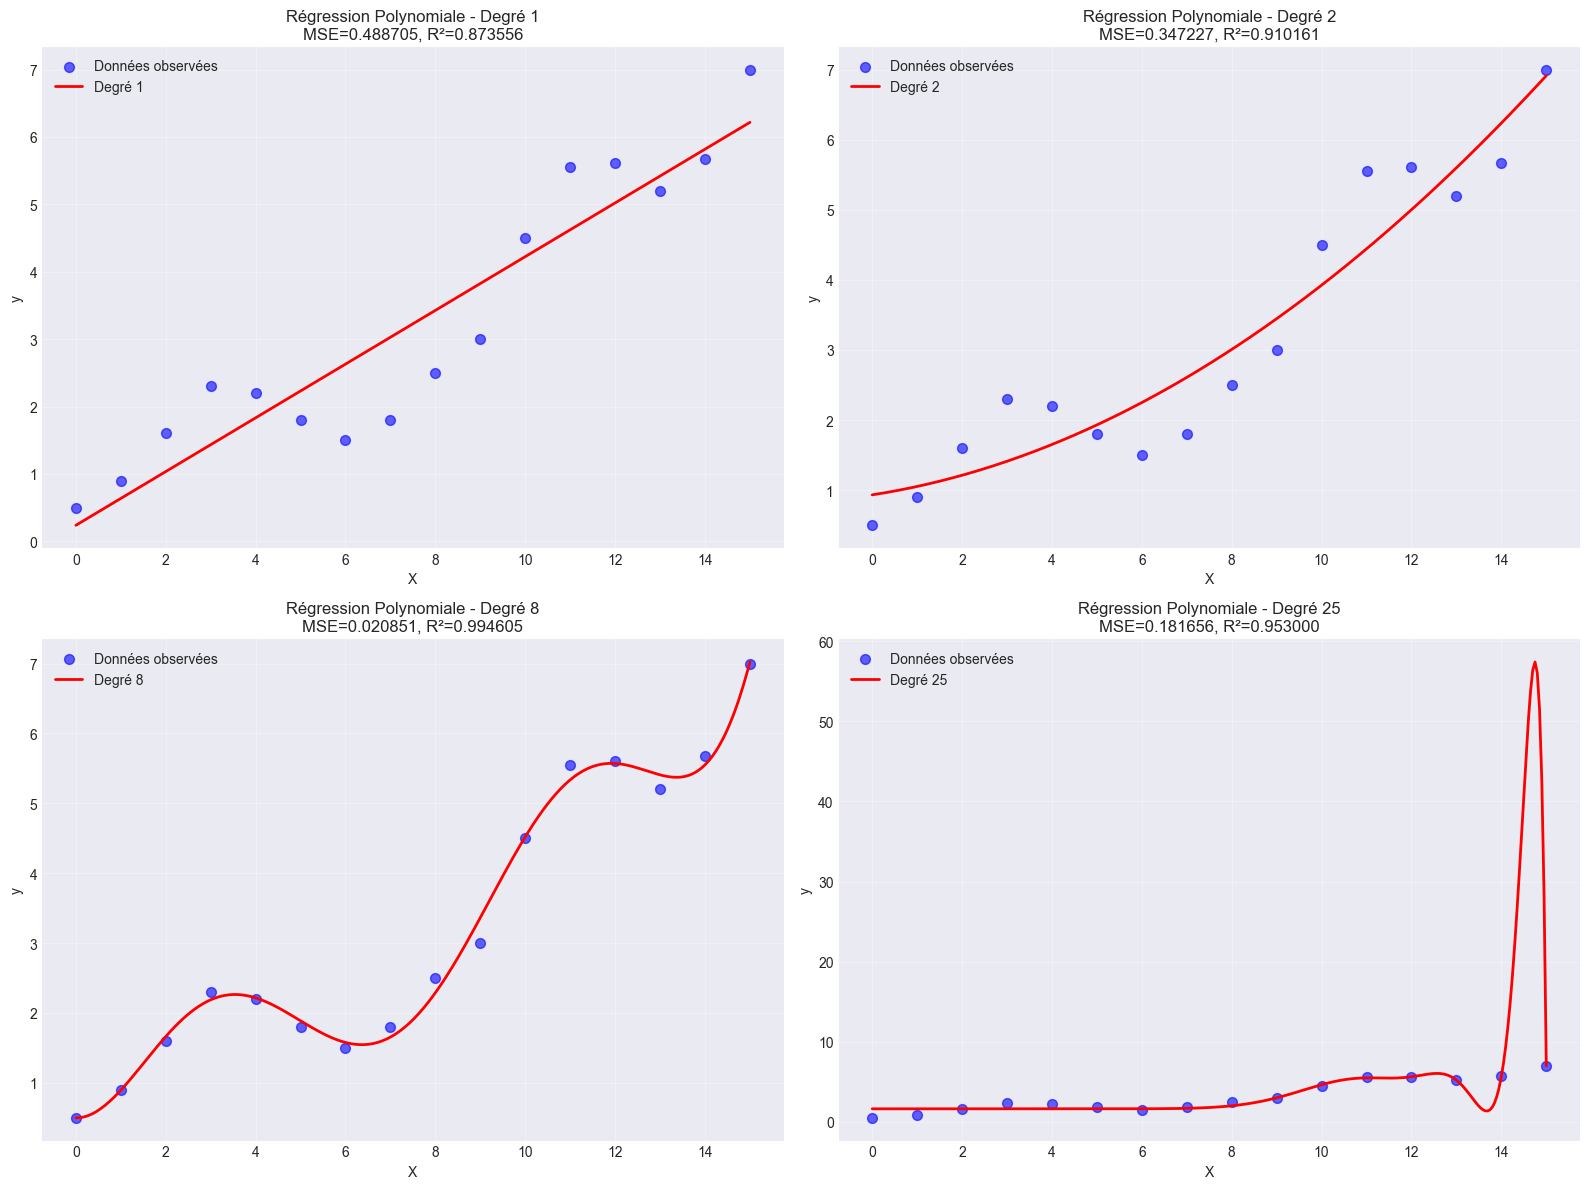

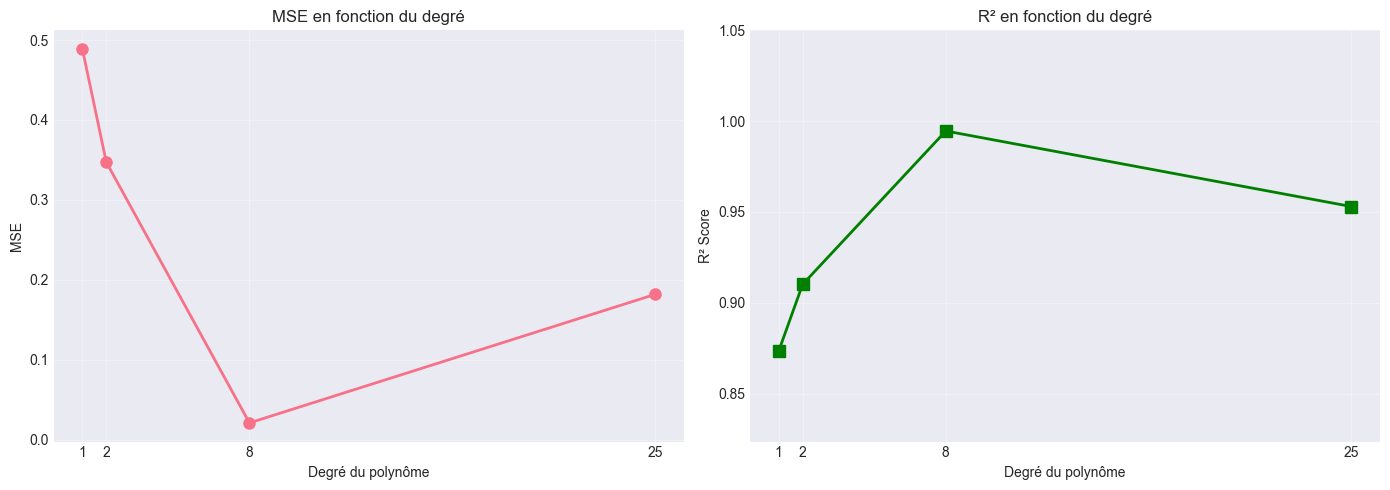


=== INTERPRÉTATION DE LA RÉGRESSION POLYNOMIALE ===

1. **UNDERFITTING (Degré 1 = Régression Linéaire)**:
   - Le modèle est trop simple pour les données
   - MSE élevé, R² faible
   - La droite ne capture pas la vraie relation

2. **BON AJUSTEMENT (Degré 2)?**:
   - Équilibre entre simplicité et ajustement
   - MSE et R² améliorés
   - La courbe suit mieux les données

3. **OVERFITTING (Degré 25)**:
   - Le modèle a trop de paramètres (26 coefficients!)
   - Apprend le bruit + la vraie relation
   - MSE très bas sur l'entraînement, mais mauvais en généralisation
   - La courbe oscille entre les points

=== POURQUOI L'EMPIRICAL RISK MINIMISATION ÉCHOUE? ===

**Quand l'espace d'hypothèse est trop grand:**

1. **Overfitting (Surapprentissage)**:
   - Trop de degrés de liberté = apprend le bruit
   - Erreur d'entraînement → 0, mais erreur de test → ∞
   - Le modèle mémorise au lieu d'apprendre

2. **Théorie de l'apprentissage**:
   - Erreur totale = Biais + Variance
   - Petit espace: Bi

In [14]:
# ============================================================================
# QUESTION 8 : Régression polynomiale avec différents degrés
# ============================================================================

# ============
# Entraîner des modèles polynomiaux avec degrés différents
# ============

# Degrés à tester
degrees = [1, 2, 8, 25]
polynomial_models = {}
results_poly = []

print("=== Régression Polynomiale ===\n")

for degree in degrees:
    # Créer les features polynomiales
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X_reg)
    
    # Entraîner le modèle
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y_reg)
    
    # Prédictions
    y_poly_pred = poly_model.predict(X_poly)
    
    # Évaluation
    mse_poly = mean_squared_error(y_reg, y_poly_pred)
    r2_poly = r2_score(y_reg, y_poly_pred)
    
    # Stocker les résultats
    polynomial_models[degree] = (poly_model, poly_features)
    results_poly.append({
        'Degree': degree,
        'MSE': mse_poly,
        'R²': r2_poly,
        'Num Coefficients': X_poly.shape[1]
    })
    
    print(f"Degré {degree}:")
    print(f"  MSE: {mse_poly:.6f}")
    print(f"  R²: {r2_poly:.6f}")
    print(f"  Nombre de coefficients: {X_poly.shape[1]}")
    print()

# Convertir en DataFrame
results_poly_df = pd.DataFrame(results_poly)
print("=== Résumé des résultats ===")
print(results_poly_df)

# ============
# Visualisation des courbes
# ============

# Générer des points pour tracer les courbes
x_smooth = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, degree in enumerate(degrees):
    ax = axes[idx]
    
    # Récupérer le modèle et les features
    poly_model, poly_features = polynomial_models[degree]
    
    # Appliquer les transformations polynomiales
    X_smooth_poly = poly_features.transform(x_smooth)
    y_smooth = poly_model.predict(X_smooth_poly)
    
    # Obtenir les coefficients pour utiliser np.polyval
    # Les coefficients de PolynomialFeatures sont dans un ordre spécifique
    # On les réorganise pour np.polyval (ordre décroissant)
    coeff = poly_model.coef_
    # Construction du polynôme: [p_d, p_{d-1}, ..., p_1, intercept]
    # np.polyval utilise cet ordre
    p = np.append(np.flip(coeff[1:]), poly_model.intercept_)
    y_smooth_polyval = np.polyval(p, x_smooth.flatten())
    
    # Graphique
    ax.scatter(X_reg, y_reg, alpha=0.6, s=50, color='blue', label='Données observées')
    ax.plot(x_smooth, y_smooth_polyval, color='red', linewidth=2, label=f'Degré {degree}')
    
    # Obtenir les métriques
    mse_d = results_poly_df[results_poly_df['Degree'] == degree]['MSE'].values[0]
    r2_d = results_poly_df[results_poly_df['Degree'] == degree]['R²'].values[0]
    
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title(f'Régression Polynomiale - Degré {degree}\nMSE={mse_d:.6f}, R²={r2_d:.6f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============
# Comparaison des métriques
# ============

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE vs Degré
axes[0].plot(results_poly_df['Degree'], results_poly_df['MSE'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Degré du polynôme')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE en fonction du degré')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(degrees)

# R² vs Degré
axes[1].plot(results_poly_df['Degree'], results_poly_df['R²'], 's-', 
             linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Degré du polynôme')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² en fonction du degré')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(degrees)
axes[1].set_ylim([min(results_poly_df['R²'])-0.05, 1.05])

plt.tight_layout()
plt.show()

print(f"""
=== INTERPRÉTATION DE LA RÉGRESSION POLYNOMIALE ===

1. **UNDERFITTING (Degré 1 = Régression Linéaire)**:
   - Le modèle est trop simple pour les données
   - MSE élevé, R² faible
   - La droite ne capture pas la vraie relation

2. **BON AJUSTEMENT (Degré 2)?**:
   - Équilibre entre simplicité et ajustement
   - MSE et R² améliorés
   - La courbe suit mieux les données

3. **OVERFITTING (Degré 25)**:
   - Le modèle a trop de paramètres ({results_poly_df[results_poly_df['Degree']==25]['Num Coefficients'].values[0]} coefficients!)
   - Apprend le bruit + la vraie relation
   - MSE très bas sur l'entraînement, mais mauvais en généralisation
   - La courbe oscille entre les points

=== POURQUOI L'EMPIRICAL RISK MINIMISATION ÉCHOUE? ===

**Quand l'espace d'hypothèse est trop grand:**

1. **Overfitting (Surapprentissage)**:
   - Trop de degrés de liberté = apprend le bruit
   - Erreur d'entraînement → 0, mais erreur de test → ∞
   - Le modèle mémorise au lieu d'apprendre

2. **Théorie de l'apprentissage**:
   - Erreur totale = Biais + Variance
   - Petit espace: Biais ↑, Variance ↓ (underfitting)
   - Grand espace: Biais ↓, Variance ↑ (overfitting)
   - Optimum à l'équilibre

3. **Complexité du modèle**:
   - Degrés croissants = complexité croissante
   - Plus de paramètres = plus de possibilités de surapprentissage
   - Il faut un compromis: l'espace d'hypothèse idéal

**Solution: Régularisation**
   - L1/L2 regularization: Pénaliser les gros coefficients
   - Cross-validation: Valider sur données non vues
   - Early stopping: Arrêter avant surapprentissage
   - Réduction de degré: Choisir un degré approprié

**Metrics clés:**
  - MSE train: {results_poly_df[results_poly_df['Degree']==1]['MSE'].values[0]:.6f} → {results_poly_df[results_poly_df['Degree']==25]['MSE'].values[0]:.6f}
  - R² train: {results_poly_df[results_poly_df['Degree']==1]['R²'].values[0]:.6f} → {results_poly_df[results_poly_df['Degree']==25]['R²'].values[0]:.6f}
""")
